
# Swiggy Analysis

Importing LIbraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Importing Data

In [2]:
df = pd.read_csv("C:/Users/91738/Downloads/combined_orders.csv")

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos 8 Pc,85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


Import Meta Data

In [5]:
print("No of Rows:",df.shape[0])

No of Rows: 197430


In [6]:
print("No of columns:",df.shape[1])

No of columns: 10


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB
None


In [8]:
df.dtypes

State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [9]:
df.describe()

,Price (INR),Rating,Rating Count
count,197430.000000,197430.000000,197430.000000
mean,268.512920,4.341582,28.321805
std,219.338363,0.422585,87.542593
min,0.950000,1.500000,0.000000
25%,139.000000,4.300000,0.000000
50%,229.000000,4.400000,2.000000
75%,329.000000,4.500000,15.000000
max,8000.000000,5.000000,999.000000


# KPI's

Total Sales

In [10]:
total_sales = df["Price (INR)"].sum()
print("Total Sales:",round(total_sales,2))

Total Sales: 53012505.77


Total Orders

In [11]:
total_orders = df['Order Date'].count()
print("Total Orders:",total_orders)

Total Orders: 197430


Average Rating

In [12]:
average_rating = df['Rating'].mean()
print("Average Rating:",round(average_rating,1))

Average Rating: 4.3


Average Order Value

In [13]:
average_order_value = total_sales/total_orders
print("Average order value:",round(average_order_value,2))

Average order value: 268.51


Ratings Count

In [14]:
rating_count = df['Rating Count'].sum()
print("Ratings Count:",rating_count)

Ratings Count: 5591574


# Charts Design

Monthly Trend

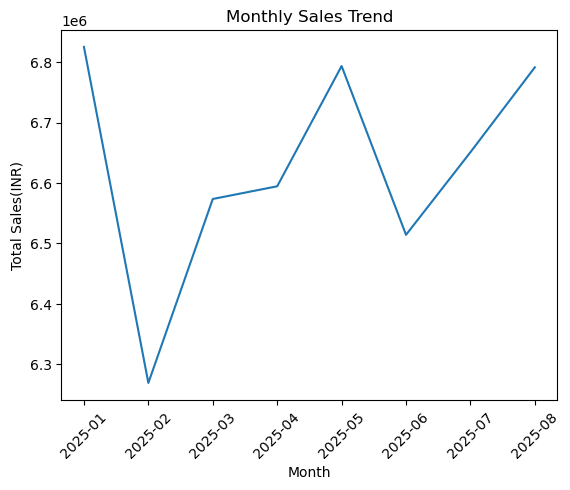

In [42]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Year Month')['Price (INR)'].sum().reset_index()
plt.figure()
plt.plot(monthly_revenue['Year Month'],monthly_revenue['Price (INR)'])
plt.xlabel('Month')
plt.ylabel('Total Sales(INR)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation = 45)
plt.show()

Daily Revenue Trend(MON-SUN)

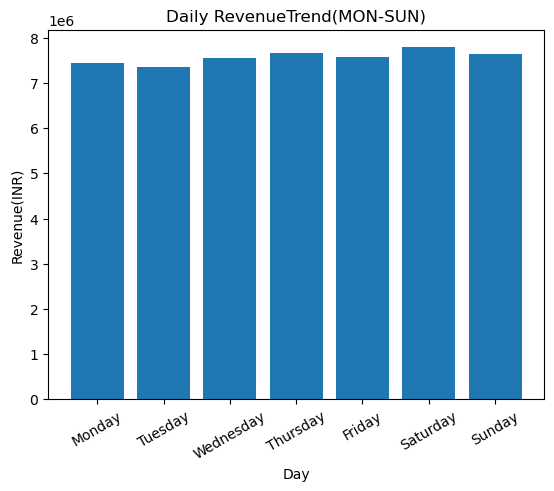

In [16]:
df['Day Name'] = pd.to_datetime(df['Order Date']).dt.day_name()
daily_revenue = df.groupby('Day Name')["Price (INR)"].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure()
plt.bar(daily_revenue.index,daily_revenue.values)
plt.xlabel("Day")
plt.ylabel("Revenue(INR)")
plt.title("Daily RevenueTrend(MON-SUN)")
plt.xticks(rotation = 30)
plt.show()

Total Sales By Food Type(Non veg vs Veg)

In [17]:
non_veg_keywords = ["chicken","egg","fish","mutton","prawn","biryani","kabab","kebab","non-veg","non veg"]
df['Food category'] = np.where(df['Dish Name'].str.lower().str.contains("|".join(non_veg_keywords),na = False),"Non Veg","Veg")

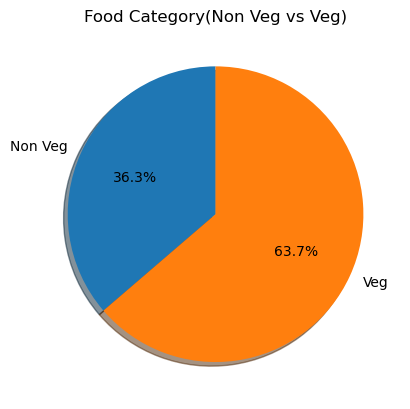

In [18]:
food_revenue = df.groupby('Food category')['Price (INR)'].sum()
plt.figure()
plt.pie(food_revenue,labels = food_revenue.index,autopct = "%1.1f%%",startangle = 90,shadow = True)
plt.title("Food Category(Non Veg vs Veg)")
plt.show()

Total Sales By State

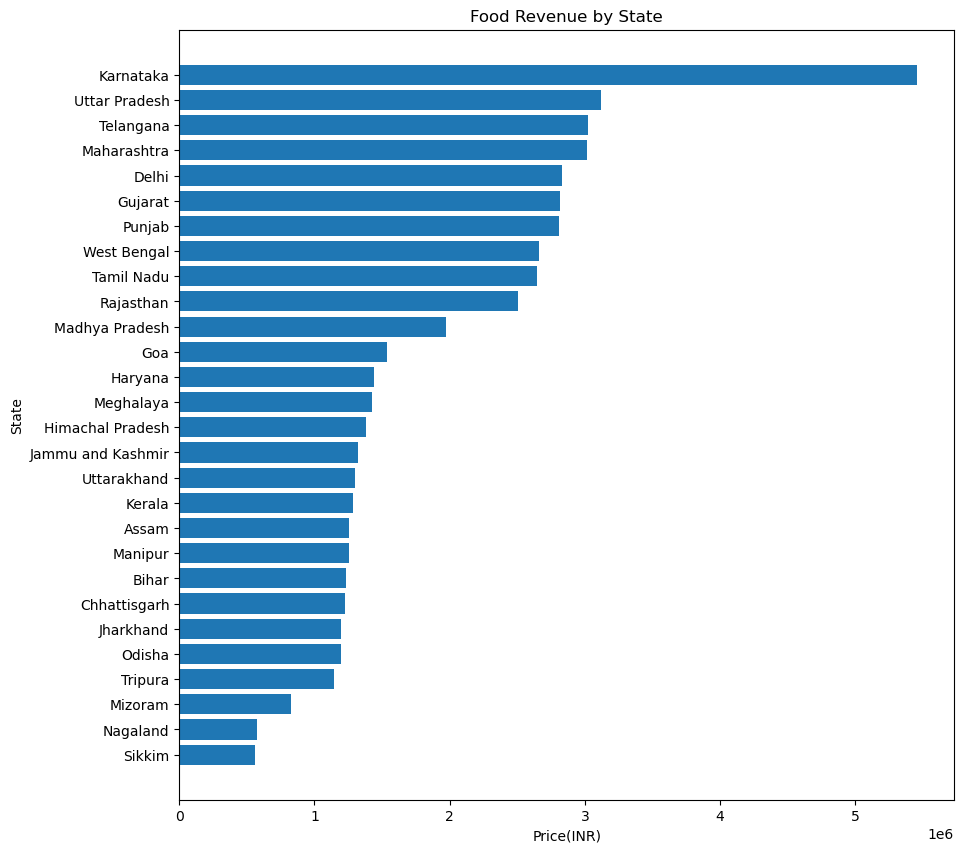

In [19]:
state_revenue = df.groupby('State')['Price (INR)'].sum().sort_values()
plt.figure(figsize = (10,10))
plt.barh(state_revenue.index,state_revenue)
plt.xlabel("Price(INR)")
plt.ylabel("State")
plt.title("Food Revenue by State")
plt.show()

Quarterly Performance Summary

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
Quarterly_summary =(df.groupby('Quarter',as_index = False).agg(
    Total_Sales = ('Price (INR)','sum'),
    Avg_Rating = ('Rating','mean'),
    Total_orders = ('Order Date','count')).sort_values('Quarter'))
Quarterly_summary['Total_Sales'] = Quarterly_summary['Total_Sales'].round(0)
Quarterly_summary['Avg_Rating'] = Quarterly_summary['Avg_Rating'].round(2)
Quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


Top 5 Cities By Sales

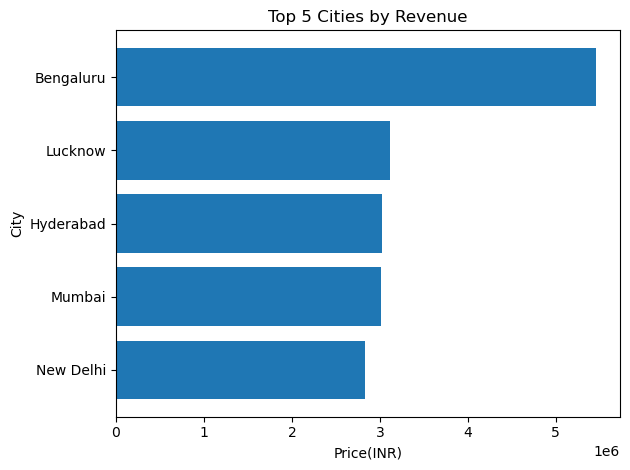

In [21]:
top_cities = df.groupby('City')['Price (INR)'].sum().nlargest(5).sort_values()
plt.figure()
plt.barh(top_cities.index,top_cities)
plt.xlabel('Price(INR)')
plt.ylabel('City')
plt.title('Top 5 Cities by Revenue')
plt.tight_layout()
plt.show()

Weekly Trend

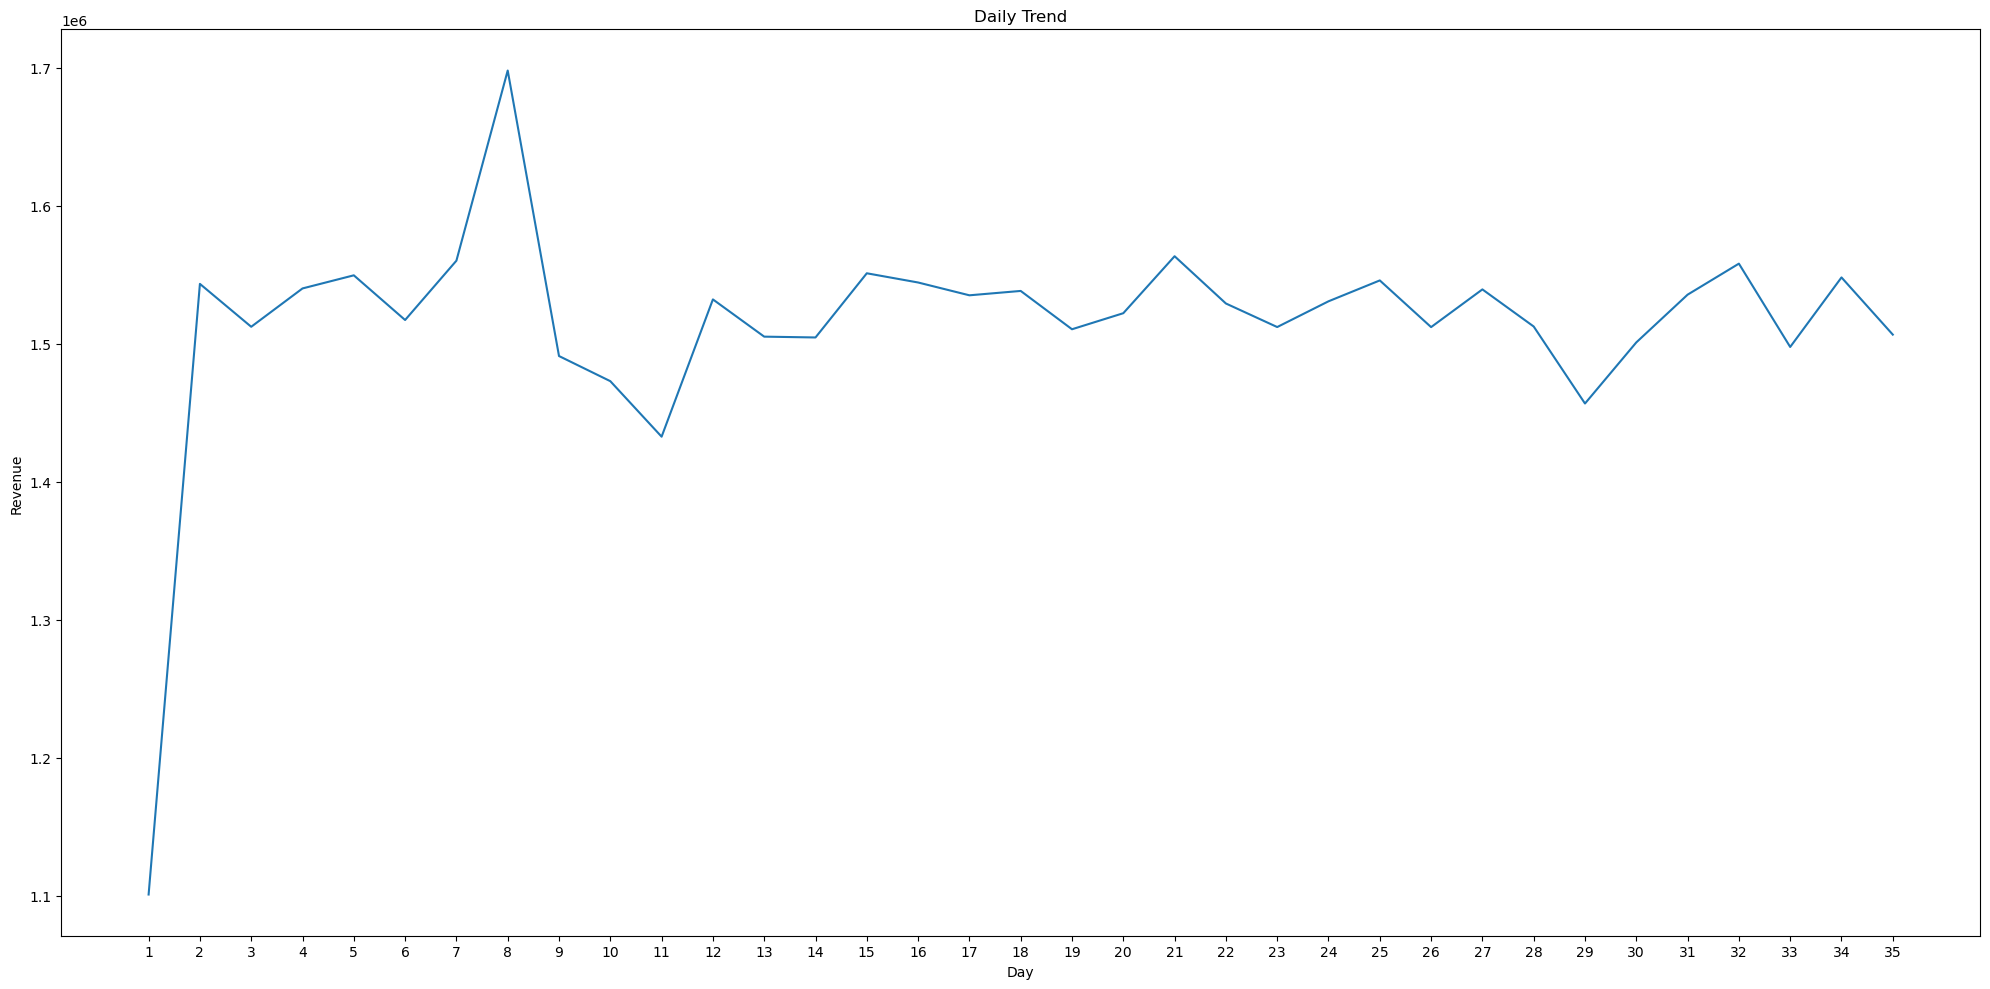

In [40]:
df['weekly'] = df['Order Date'].dt.isocalendar().week
weekly_revenue = df.groupby('weekly',as_index = False)['Price (INR)'].sum()
plt.figure(figsize = (20,10))
plt.plot(weekly_revenue['weekly'],weekly_revenue['Price (INR)'])
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.title('Daily Trend')
plt.xticks(weekly_revenue['weekly'])
plt.tight_layout()
plt.show()